In [1]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [3]:
image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

In [4]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)

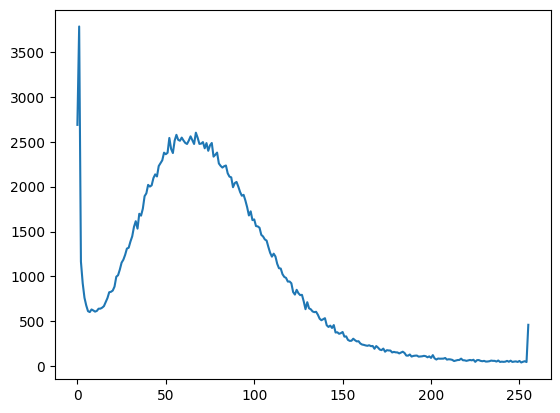

In [5]:
plt.plot(b_hist)

In [6]:
gamma = 0.5
corrected_l = (((image_gray / image_gray.max()) ** gamma) * image_gray.max()).astype(np.uint8)
gamma = 2.0
corrected_u = (((image_gray / image_gray.max()) ** gamma) * image_gray.max()).astype(np.uint8)


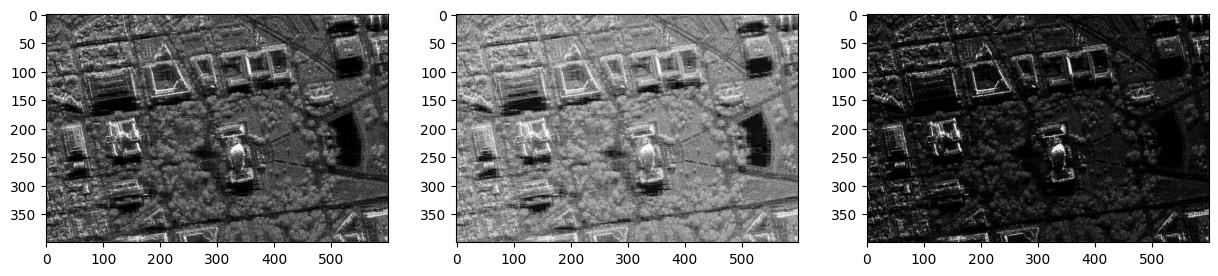

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
ax[0].imshow(image_gray, cmap="gray")
ax[1].imshow(corrected_l, cmap="gray")
ax[2].imshow(corrected_u, cmap="gray")

In [8]:
ssim, _ = structural_similarity(image_gray, corrected_l, full=True)
mse = mean_squared_error(image_gray, corrected_l)
print(f"SSIM: {ssim}, MSE: {mse}")
ssim, _ = structural_similarity(image_gray, corrected_u, full=True)
mse = mean_squared_error(image_gray, corrected_u)
print(f"SSIM: {ssim}, MSE: {mse}")

SSIM: 0.7875008686792752, MSE: 3250.429145833333
SSIM: 0.5270459922820343, MSE: 2383.7636375


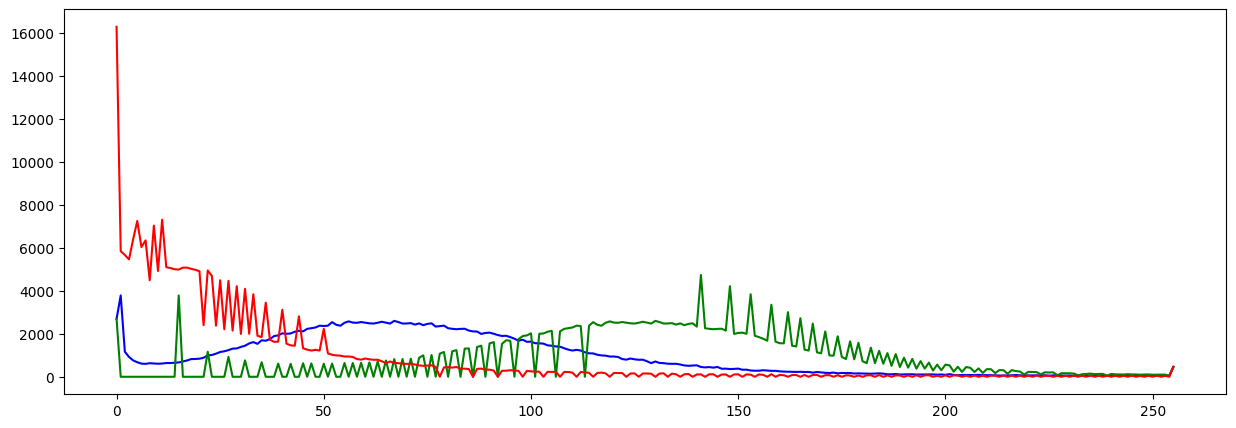

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate), color='blue')
plt.plot(cv2.calcHist([corrected_l], [0], None, [histSize], histRange, accumulate=accumulate), color='green')
plt.plot(cv2.calcHist([corrected_u], [0], None, [histSize], histRange, accumulate=accumulate), color='red')

In [10]:
eq_gray = cv2.equalizeHist(image_gray)

In [11]:
E_t = image_gray.sum() / (image_gray.shape[0] * image_gray.shape[1])
D_t = np.sqrt(
    (((image_gray - E_t) ** 2).sum() / (image_gray.shape[0] * image_gray.shape[1]))
)
E_s = eq_gray.sum() / (eq_gray.shape[0] * eq_gray.shape[1])
D_s = np.sqrt(
    (((eq_gray - E_s) ** 2).sum() / (eq_gray.shape[0] * eq_gray.shape[1]))
)

E_t, D_t, E_s, D_s

(np.float64(74.94157083333333),
 np.float64(43.658465466227916),
 np.float64(127.02563333333333),
 np.float64(74.26964841889017))

In [12]:
stat_corr = (E_s + (image_gray - E_t) * D_s / D_t).astype(np.uint8)
stat_corr

array([[ 38,  77, 108, ..., 196,  70,  93],
       [127, 128, 110, ..., 178,  22, 167],
       [127, 108,  72, ..., 150, 218, 177],
       ...,
       [237, 108, 152, ...,  31, 232, 195],
       [213, 167, 144, ...,  32, 235,  29],
       [195, 152, 154, ..., 159, 150,  76]], shape=(400, 600), dtype=uint8)

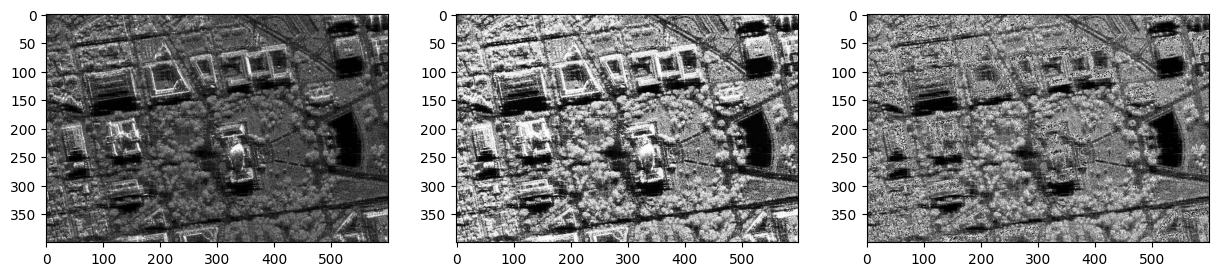

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
ax[0].imshow(image_gray, cmap="gray")
ax[1].imshow(eq_gray, cmap="gray")
ax[2].imshow(stat_corr, cmap="gray")

''

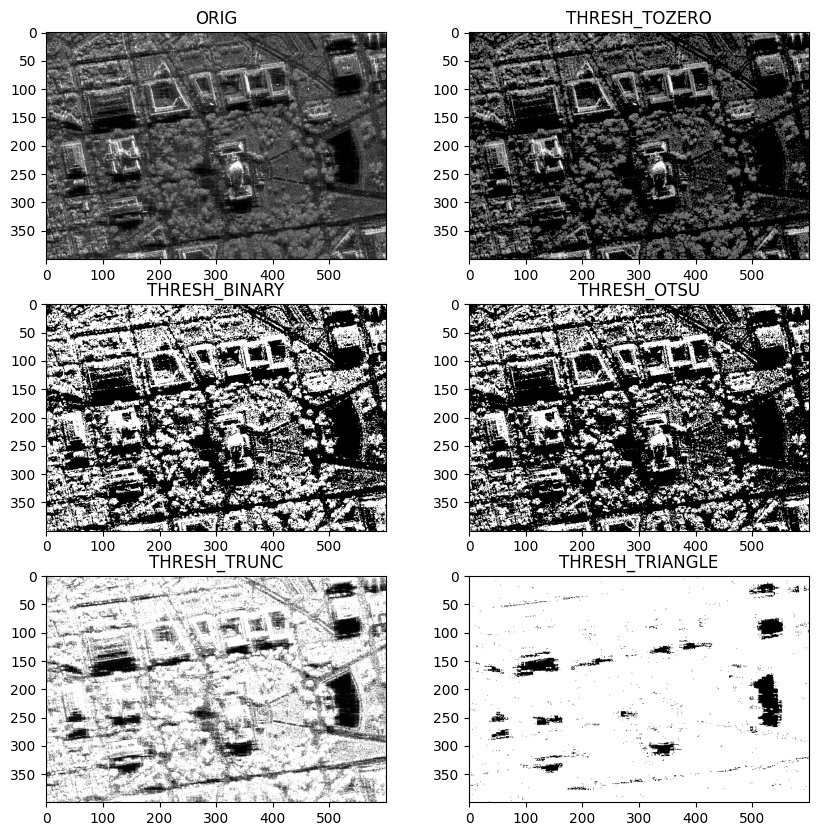

In [14]:
# THRESH_BINARY: int
# THRESH_BINARY_INV: int
# THRESH_TRUNC: int
# THRESH_TOZERO: int
# THRESH_TOZERO_INV: int
# THRESH_MASK: int
# THRESH_OTSU: int
# THRESH_TRIANGLE: int
# THRESH_DRYRUN: int
TRESH = image_gray.mean()
TRESH = image_gray.mean()
MAXVAL = image_gray.max()

fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0][0].imshow(image_gray, cmap="gray")
ax[0][0].set_title('ORIG')

_, thresh = cv2.threshold(image_gray, TRESH, MAXVAL, cv2.THRESH_TOZERO)
ax[0][1].imshow(thresh, cmap="gray")
ax[0][1].set_title('THRESH_TOZERO')

_, thresh = cv2.threshold(image_gray, TRESH, MAXVAL, cv2.THRESH_BINARY)
ax[1][0].imshow(thresh, cmap="gray")
ax[1][0].set_title('THRESH_BINARY')

_, thresh = cv2.threshold(image_gray, TRESH, MAXVAL, cv2.THRESH_OTSU)
ax[1][1].imshow(thresh, cmap="gray")
ax[1][1].set_title('THRESH_OTSU')

_, thresh = cv2.threshold(image_gray, TRESH, MAXVAL, cv2.THRESH_TRUNC)
ax[2][0].imshow(thresh, cmap="gray")
ax[2][0].set_title('THRESH_TRUNC')

_, thresh = cv2.threshold(image_gray, TRESH, MAXVAL, cv2.THRESH_TRIANGLE)
ax[2][1].imshow(thresh, cmap="gray")
ax[2][1].set_title('THRESH_TRIANGLE')
;


In [15]:
im1 = image_gray
im2 = eq_gray

m1 = im1.mean()
m2 = im2.mean()

d1 = im1.std()
d2 = im2.std()

m1, m2, d1, d2

(np.float64(74.94157083333333),
 np.float64(127.02563333333333),
 np.float64(43.658465466227916),
 np.float64(74.26964841889017))

In [16]:
def cmp1(im1, im2, t):
    m1, d1 = im1.mean(), im1.std()
    m2, d2 = im2.mean(), im2.std()
    return int(abs(m1 - m2) < t and abs(d1 - d2) < t)

def cmp2(im1, im2, t):
    m1, d1 = im1.mean(), im1.std()
    m2, d2 = im2.mean(), im2.std()
    return int(((m1 - m2) ** 2 + (d1 - d2)**2) ** (1/2) < t)

In [17]:
m1 - m2, d1 - d2

(np.float64(-52.0840625), np.float64(-30.611182952662254))

In [18]:
t = 10
cmp1(im1, im2, t), cmp2(im1, im2, t)

(0, 0)

In [19]:
t = 60
cmp1(im1, im2, t), cmp2(im1, im2, t)

(1, 0)

In [20]:
t = 70
cmp1(im1, im2, t), cmp2(im1, im2, t)

(1, 1)